In [17]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [18]:
import shutil
import os

cache_path = kagglehub.competition_download("carvana-image-masking-challenge")

target_path = "/content/carvana_data"
os.makedirs(target_path, exist_ok=True)

for file_name in os.listdir(cache_path):
    source = os.path.join(cache_path, file_name)
    destination = os.path.join(target_path, file_name)

    if os.path.exists(destination):
        if os.path.isdir(destination):
            shutil.rmtree(destination)
        else:
            os.remove(destination)

    shutil.move(source, target_path)

print(os.listdir(target_path))

['train.zip', 'test_hq.zip', 'metadata.csv.zip', 'train', 'sample_submission.csv.zip', 'train_masks.csv.zip', 'train_hq.zip', 'train_masks', 'test.zip', 'test', '29bb3ece3180_11.jpg', 'train_masks.zip']


In [19]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Images

In [20]:
import zipfile

with zipfile.ZipFile('/content/carvana_data/train.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/carvana_data/')

with zipfile.ZipFile('/content/carvana_data/test.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/carvana_data/')

Masks

In [21]:
with zipfile.ZipFile('/content/carvana_data/train_masks.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/carvana_data/')

In [44]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CarSegmentation(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))

        self.image_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image_path = os.path.join(self.img_dir, self.images[i])
        mask_path = os.path.join(self.mask_dir, self.masks[i])

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.image_transform(image)
        mask = self.mask_transform(mask)

        return image, mask

In [45]:
train_img_path = '/content/carvana_data/train'
train_mask_path = '/content/carvana_data/train_masks'
test_path = '/content/carvana_data/test'

train_dataset = CarSegmentation(train_img_path, train_mask_path)

train_loader = DataLoader(train_dataset, batch_size=16)

In [46]:
import torch.nn as nn

class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.conv =  nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        ),
    nn.ReLU(),

    nn.Conv2d(
      out_channels,
      out_channels,
      kernel_size=3,
      padding=1
    ),
    nn.ReLU()
    )

  def forward(self, x):
    return self.conv(x)

In [47]:
class UNet(nn.Module):
  def __init__(self):
    super().__init__()

    # Encoder
    self.encoder1 = DoubleConv(3, 64)
    self.encoder2 = DoubleConv(64, 128)
    self.encoder3 = DoubleConv(128, 256)

    self.pool = nn.MaxPool2d(2)
    self.bottleneck = DoubleConv(256, 512)

    # Decoder
    self.up3 = nn.ConvTranspose2d(
        512, 256,
        kernel_size=2,
        stride=2
    )
    self.decoder3 = DoubleConv(512, 256)

    self.up2 = nn.ConvTranspose2d(
        256, 128,
        kernel_size=2,
        stride=2
    )
    self.decoder2 = DoubleConv(256, 128)

    self.up1 = nn.ConvTranspose2d(
        128, 64,
        kernel_size=2,
        stride=2
    )
    self.decoder1 = DoubleConv(128, 64)

    # Final layer
    self.final = nn.Conv2d(
        64,
        1,
        kernel_size=1
    )

  def forward(self, x):
    # Encoder
    e1 = self.encoder1(x) # 256x256
    e2 = self.encoder2(self.pool(e1)) # 128x128
    e3 = self.encoder3(self.pool(e2)) # 64x64

    # Bottleneck
    b = self.bottleneck(self.pool(e3)) # 32x32

    # Decoder
    d3 = self.up3(b) # 64x64
    d3 = torch.cat([d3, e3], dim=1)
    d3 = self.decoder3(d3)

    d2 = self.up2(d3) # 128x128
    d2 = torch.cat([d2, e2], dim=1)
    d2 = self.decoder2(d2)

    d1 = self.up1(d2) # 256x256
    d1 = torch.cat([d1, e1], dim=1)
    d1 = self.decoder1(d1)

    # Output mask
    return self.final(d1)


In [48]:
model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [49]:
epoches = 10

for epoch in range(epoches):
  model.train()

  for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    prediction = model(images)
    loss = criterion(prediction, masks)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    torch.save(model.state_dict(), f'unet_weights{epoch+1}.pth')
  print(f"Epoch: {epoch + 1}, loss: {loss.item():.4f}")

Epoch: 1, loss: 0.1272
Epoch: 2, loss: 0.0782
Epoch: 3, loss: 0.0580
Epoch: 4, loss: 0.0439
Epoch: 5, loss: 0.0540
Epoch: 6, loss: 0.0236
Epoch: 7, loss: 0.0176
Epoch: 8, loss: 0.0241
Epoch: 9, loss: 0.0315
Epoch: 10, loss: 0.0163


In [56]:
import numpy as np

model = UNet()
weights = torch.load('unet_weights9.pth')
model.load_state_dict(weights)
model.eval()

image_path = '/content/carvana_data/test/0004d4463b50_01.jpg'
original_image = Image.open(image_path).convert("RGB")
orig_w, orig_h = original_image.size

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

input_tensor = transform(original_image).unsqueeze(0) # added batch [3, 256, 256] -> [1, 3, 256, 256]

with torch.no_grad():
  prediction = model(input_tensor)

  probabilities = torch.sigmoid(prediction) # it makes prediction in the range 0.0-1.0

  pred_mask = (probabilities > 0.5).float()

pred_mask = pred_mask.squeeze().cpu().numpy() # it turns the tensor into a picture [1, 1, 256, 256] -> [256, 256]

pred_mask_image = (pred_mask * 255).astype(np.uint8) #
result_image = Image.fromarray(pred_mask_image)

result_image = result_image.resize((orig_w, orig_h), Image.Resampling.NEAREST)

result_image.save("predicted_mask.png")

In [59]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

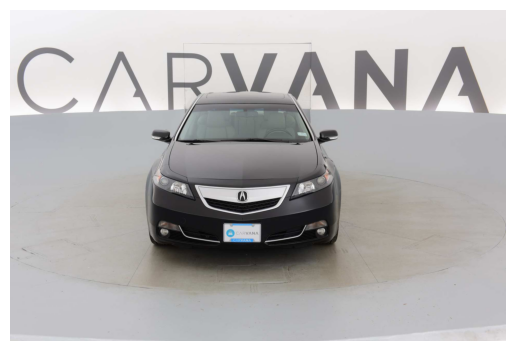

In [62]:
img = mpimg.imread('/content/carvana_data/test/0004d4463b50_01.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

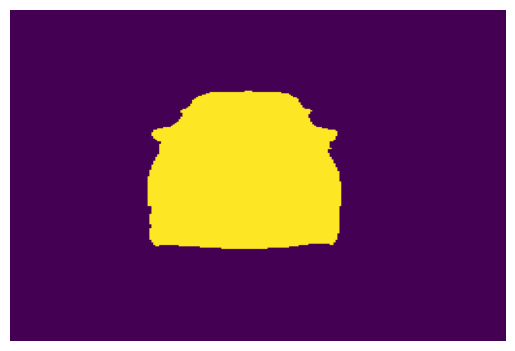

In [60]:
img = mpimg.imread('predicted_mask.png')
plt.imshow(img)
plt.axis('off')
plt.show()